# IMPORTS

In [ ]:
import pandas as pd
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PATH SETTINGS

In [ ]:
TRAINING_FOLDERS = {
    0: r"C:\FinalDataset\dataset\dataset\1 star",
    1: r"C:\FinalDataset\dataset\dataset\2 star",
    2: r"C:\FinalDataset\dataset\dataset\3 star",
    3: r"C:\FinalDataset\dataset\dataset\4 star",
    4: r"C:\FinalDataset\dataset\dataset\5 star"
}
MODEL_SAVE_TRANSFORMER = r"C:\Anti\transformer_model_trial.h5"
MODEL_SAVE_LSTM = r"C:\Anti\lstm_model_trial.h5"
SCALER_SAVE = r"C:\Anti\scaler31.pkl"
TEST_FILE = r"C:\Sample1data\1 star\Daniyal_aggresive2.csv"

# SETTINGS

In [ ]:
WINDOW_SIZE = 120
STEP_SIZE = 20

FEATURES = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z','acc_mag','gyro_mag']
LABEL_NAMES = ['Aggressive', 'Rush', 'Moderate', 'Smooth', 'Safe']

# LOAD + WINDOW DATA

In [ ]:
print("\n[1] Loading Dataset...")

X, y = [], []

for label, folder in TRAINING_FOLDERS.items():
    print(f"Processing: {folder}")

    csv_files = glob.glob(os.path.join(folder, "*.csv"))

    for file in csv_files:
        try:
            df = pd.read_csv(file)

            # Fix column names
            if 'X_Acc' in df.columns:
                df.rename(columns={
                    'X_Acc': 'acc_x', 'Y_Acc': 'acc_y', 'Z_Acc': 'acc_z',
                    'X_Gyro': 'gyro_x', 'Y_Gyro': 'gyro_y', 'Z_Gyro': 'gyro_z'
                }, inplace=True)

            # Safety check
            if not all(col in df.columns for col in ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']):
                print(f"Skipping {file}")
                continue

            #  Feature Engineering
            df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
            df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

            values = df[FEATURES].values.astype(np.float32)

            for i in range(0, len(values) - WINDOW_SIZE, STEP_SIZE):
                X.append(values[i:i + WINDOW_SIZE])
                y.append(label)

        except Exception as e:
            print(f"Error in {file}: {e}")

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)


[1] Loading Dataset...
Processing: C:\FinalDataset\dataset\dataset\1 star
Processing: C:\FinalDataset\dataset\dataset\2 star
Processing: C:\FinalDataset\dataset\dataset\3 star
Processing: C:\FinalDataset\dataset\dataset\4 star
Skipping C:\FinalDataset\dataset\dataset\4 star\Lokesh_safe1.csv
Processing: C:\FinalDataset\dataset\dataset\5 star
Dataset Shape: (145711, 120, 8)


# SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("\nClass Weights:", class_weights)


Class Weights: {np.int64(0): np.float64(1.0233342112193837), np.int64(1): np.float64(0.9180389840519787), np.int64(2): np.float64(0.8647798508846767), np.int64(3): np.float64(0.9751380291115944), np.int64(4): np.float64(1.330381191508788)}


# SCALING

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, len(FEATURES)))

X_train = scaler.transform(X_train.reshape(-1, len(FEATURES))).reshape(len(X_train), WINDOW_SIZE, len(FEATURES))
X_test = scaler.transform(X_test.reshape(-1, len(FEATURES))).reshape(len(X_test), WINDOW_SIZE, len(FEATURES))

with open(SCALER_SAVE, 'wb') as f:  
    pickle.dump(scaler, f)

# MODEL BUILDING 

In [7]:
# ============================================================
# MODEL BUILDING (CNN + BIDIRECTIONAL LSTM)
# ============================================================
from tensorflow.keras.layers import Conv1D, MaxPooling1D

lstm_model= Sequential([
    # CNN PART (detects local patterns)
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(FEATURES))),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # LSTM PART (sequence learning)
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    
    # DENSE PART
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


c:\Users\daniy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 118, 64)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 116, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 58, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 58, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 58, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 58, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,437 (1.47 MB)

 Trainable params: 386,437 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

# TRAINING

In [ ]:
print("\n[2] Training LSTM File...")
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

y_train_final = to_categorical(y_train_final, 5)
y_val = to_categorical(y_val, 5)
y_test_cat = to_categorical(y_test, 5)

history = lstm_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights
)

lstm_model.save(MODEL_SAVE_LSTM)

print("Training Complete!")



[2] Training LSTM File...
Epoch 1/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 131s 82ms/step - accuracy: 0.6176 - loss: 0.8906 - val_accuracy: 0.7394 - val_loss: 0.6347
Epoch 2/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 129s 83ms/step - accuracy: 0.7525 - loss: 0.5845 - val_accuracy: 0.7638 - val_loss: 0.5523
Epoch 3/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 130s 84ms/step - accuracy: 0.7826 - loss: 0.5122 - val_accuracy: 0.7978 - val_loss: 0.4563
Epoch 4/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 130s 84ms/step - accuracy: 0.7970 - loss: 0.4691 - val_accuracy: 0.8149 - val_loss: 0.4080
Epoch 5/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 141s 83ms/step - accuracy: 0.8129 - loss: 0.4314 - val_accuracy: 0.8244 - val_loss: 0.3768
Epoch 6/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 130s 84ms/step - accuracy: 0.8209 - loss: 0.4078 - val_accuracy: 0.8366 - val_loss: 0.3808
Epoch 7/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 142s 84ms/step - accuracy: 0.8302 - loss: 0.3880 - val_accuracy: 0.8367 - val_loss: 0.3511
Epoch 8/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 

Training Complete!


Transformer Model

In [9]:
# ============================================================
# MODEL BUILDING (UPGRADED TRANSFORMER)
# ============================================================
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
    Conv1D, MaxPooling1D, Embedding, Layer
)
from tensorflow.keras.models import Model

# 1. Tiny Positional Embedding Layer so the transformer understands Time
class PositionEmbedding(Layer):
    def __init__(self, maxlen, embed_dim):
        super(PositionEmbedding, self).__init__()
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-2]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        return x + positions

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # Self Attention
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed Forward Network
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)

    return LayerNormalization(epsilon=1e-6)(x + ffn)

# Input Layer
inputs = Input(shape=(WINDOW_SIZE, len(FEATURES)))

# ========================================
# ADDED: CNN Feature Extractor
# ========================================
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
x = MaxPooling1D(pool_size=2, padding='same')(x) # Drops sequence length to 100

# ========================================
# ADDED: Positional Embeddings
# ========================================
# Max sequence length is now WINDOW_SIZE // 2 (100) and feature dim is 64
x = PositionEmbedding(maxlen=100, embed_dim=64)(x)

# Transformer Encoder Block
x = transformer_encoder(
    x,
    head_size=64, # Matches the 64 filters of the Conv1D
    num_heads=4,
    ff_dim=128,
    dropout=0.3
)

# Global Pooling
x = GlobalAveragePooling1D()(x)

# Dense Layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)

# Output Layer
outputs = Dense(5, activation='softmax')(x)

# Creating the Model
transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 120, 64)   │      1,600 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 60, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 60, 64)    │      6,400 │ max_pooling1d_1[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     66,368 │ position_embeddi… │
│ (MultiHeadAttentio… │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 60, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 64)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 60, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 60, 64)    │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        165 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 97,605 (381.27 KB)

 Trainable params: 97,605 (381.27 KB)

 Non-trainable params: 0 (0.00 B)

Trainning Model

In [10]:
print("\n[2] Training Transformer File...")
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

y_train_final = to_categorical(y_train_final, 5)
y_val = to_categorical(y_val, 5)
y_test_cat = to_categorical(y_test, 5)

history = transformer_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights
)

transformer_model.save(MODEL_SAVE_TRANSFORMER)

print("Training Complete of Transformer!")


[2] Training Transformer File...
Epoch 1/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 56s 34ms/step - accuracy: 0.6271 - loss: 0.8699 - val_accuracy: 0.7628 - val_loss: 0.5562
Epoch 2/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7566 - loss: 0.5699 - val_accuracy: 0.7950 - val_loss: 0.4754
Epoch 3/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7825 - loss: 0.5000 - val_accuracy: 0.8205 - val_loss: 0.4190
Epoch 4/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.8001 - loss: 0.4589 - val_accuracy: 0.8189 - val_loss: 0.4134
Epoch 5/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.8079 - loss: 0.4345 - val_accuracy: 0.8019 - val_loss: 0.4978
Epoch 6/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.8175 - loss: 0.4139 - val_accuracy: 0.8257 - val_loss: 0.3922
Epoch 7/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8249 - loss: 0.3972 - val_accuracy: 0.8295 - val_loss: 0.3929
Epoch 8/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 

Training Complete of Transformer!


# EVALUATION

In [11]:

print("\nLSTM Classification Report:\n")
lstm_probs = lstm_model.predict(X_test)
lstm_pred = np.argmax(lstm_probs, axis=1)
print(classification_report(y_test, lstm_pred, target_names=LABEL_NAMES))

print("\nTransformer Classification Report:\n")
transformer_probs = transformer_model.predict(X_test)
transformer_pred = np.argmax(transformer_probs, axis=1)
print(classification_report(y_test, transformer_pred, target_names=LABEL_NAMES))



LSTM Classification Report:

911/911 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step
              precision    recall  f1-score   support

  Aggressive       0.86      0.89      0.88      5696
        Rush       0.97      0.93      0.95      6349
    Moderate       0.96      0.87      0.92      6740
      Smooth       0.75      0.89      0.82      5977
        Safe       0.88      0.82      0.85      4381

    accuracy                           0.88     29143
   macro avg       0.89      0.88      0.88     29143
weighted avg       0.89      0.88      0.89     29143


Transformer Classification Report:

911/911 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
              precision    recall  f1-score   support

  Aggressive       0.79      0.91      0.84      5696
        Rush       0.93      0.90      0.91      6349
    Moderate       0.93      0.86      0.89      6740
      Smooth       0.77      0.84      0.80      5977
        Safe       0.85      0.73      0.78      4381

    accuracy                      

Accuracy Comparison


LSTM Accuracy: 0.8839515492571115
Transformer Accuracy: 0.8516968054078167


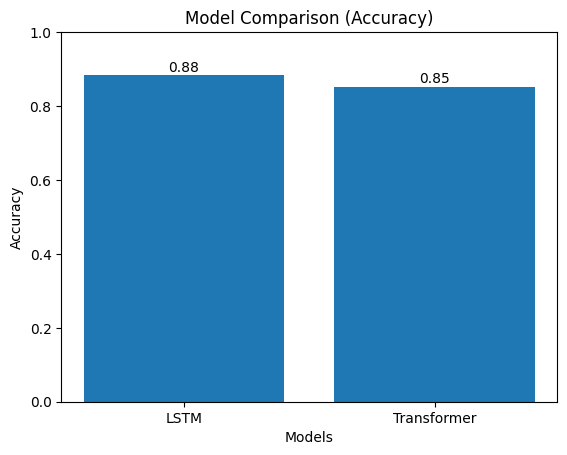

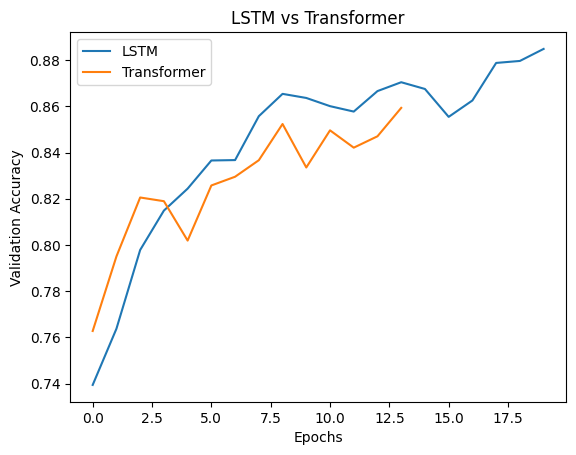

In [12]:
# ================= ACCURACY =================
lstm_acc = accuracy_score(y_test, lstm_pred)
transformer_acc = accuracy_score(y_test, transformer_pred)

print("\nLSTM Accuracy:", lstm_acc)
print("Transformer Accuracy:", transformer_acc)

# ================= BAR GRAPH =================
models = ['LSTM', 'Transformer']
accuracies = [lstm_acc, transformer_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

plt.figure()

plt.plot(lstm_model.history.history['val_accuracy'], label='LSTM')
plt.plot(transformer_model.history.history['val_accuracy'], label='Transformer')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("LSTM vs Transformer")

plt.legend()
plt.show()

# CONFUSION MATRIX

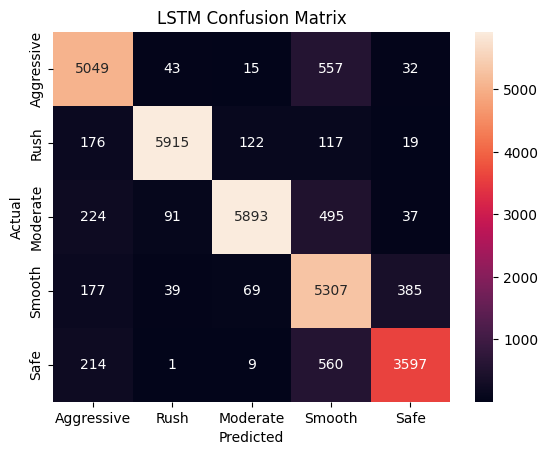

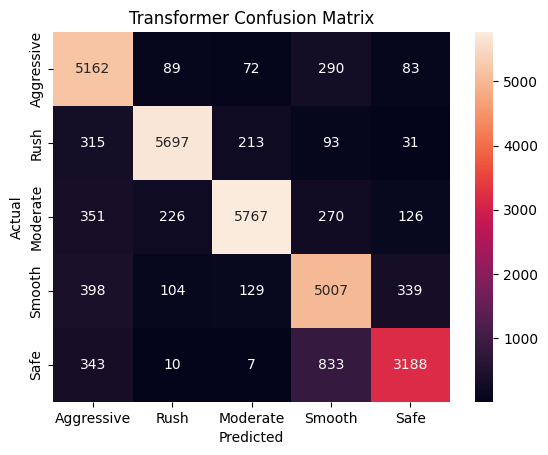

In [ ]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

plt.figure()
sns.heatmap(cm_lstm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

cm_transformer = confusion_matrix(y_test, transformer_pred)

plt.figure()
sns.heatmap(cm_transformer, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transformer Confusion Matrix")
plt.show()


# DRIVING SCORE FUNCTION

In [ ]:
def calculate_driving_score(predictions):
    avg_probs = np.mean(predictions, axis=0)
    weights = np.array([20, 40, 60, 80, 100])
    return round(np.dot(avg_probs, weights), 2)


# TEST FUNCTION

In [21]:
def test_on_file(csv_path):

    df = pd.read_csv(csv_path)

    if 'X_Acc' in df.columns:
        df.rename(columns={
            'X_Acc': 'acc_x', 'Y_Acc': 'acc_y', 'Z_Acc': 'acc_z',
            'X_Gyro': 'gyro_x', 'Y_Gyro': 'gyro_y', 'Z_Gyro': 'gyro_z'
        }, inplace=True)

    # Feature Engineering
    df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

    
    data = df[FEATURES].values

    windows = [
        data[i:i + WINDOW_SIZE]
        for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE)
    ]

    if len(windows) == 0:
        print("Not enough data!")
        return

    X_val = np.array(windows)
    X_val = scaler.transform(X_val.reshape(-1, len(FEATURES))).reshape(len(X_val), WINDOW_SIZE, len(FEATURES))

   # TEST LSTM

    preds_lstm = lstm_model.predict(X_val, verbose=0) # verbose=0 hides the progress bar for cleaner output
    score_lstm = calculate_driving_score(preds_lstm)
    avg_probs_lstm = np.mean(preds_lstm, axis=0)
    pred_class_lstm = np.argmax(avg_probs_lstm)
    print("\n" + "="*40)
    print("LSTM  MODEL PREDICTION")
    print("="*40)
    print(f"Driving Score: {score_lstm}/100")
    print(f"Driving Style: {LABEL_NAMES[pred_class_lstm]}")
    
    
    # 2. TEST TRANSFORMER
 
    preds_trans = transformer_model.predict(X_val, verbose=0)
    score_trans = calculate_driving_score(preds_trans)
    avg_probs_trans = np.mean(preds_trans, axis=0)
    pred_class_trans = np.argmax(avg_probs_trans)
    
    print("\n" + "="*40)
    print("TRANSFORMER MODEL PREDICTION")
    print("="*40)
    print(f"Driving Score: {score_trans}/100")
    print(f"Driving Style: {LABEL_NAMES[pred_class_trans]}")


# RUN TEST

In [22]:
print(f"Test File Name {TEST_FILE}")
if os.path.exists(TEST_FILE):
    test_on_file(TEST_FILE)
else:
    print("Test file not found!")

Test File Name C:\Sample1data\1 star\Daniyal_aggresive2.csv

LSTM  MODEL PREDICTION
Driving Score: 22.85/100
Driving Style: Aggressive

TRANSFORMER MODEL PREDICTION
Driving Score: 31.25/100
Driving Style: Aggressive
